### Евсеев ИУ5-64Б Семинар 8


Запуск config1: capacity=6 (без ухода)
Привет! Это клиент1, и я прибыл в магазин в 14 (сек)
Привет! Это клиент2, и я прибыл в магазин в 38 (сек)
Привет! Это клиент3, и я прибыл в магазин в 210 (сек)
Привет! Это клиент4, и я прибыл в магазин в 274 (сек)
Привет! Это клиент5, и я прибыл в магазин в 363 (сек)
Привет! Это клиент6, и я прибыл в магазин в 491 (сек)
Привет! Это клиент7, и я прибыл в магазин в 513 (сек)
Привет! Это клиент8, и я прибыл в магазин в 564 (сек)
Я клиент1, обслуживался 622 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=636) я ушёл.
Я клиент2, обслуживался 610 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=648) я ушёл.
Привет! Это клиент9, и я прибыл в магазин в 691 (сек)
Я клиент7, обслуживался 131 секунд, ждал в очереди 123 секунд
Меня обслужили, и сейчас (время=767) я ушёл.
Я клиент3, обслуживался 561 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=771) я ушёл.
Привет! Это клиент10, и я прибыл в магазин в 852 (сек)


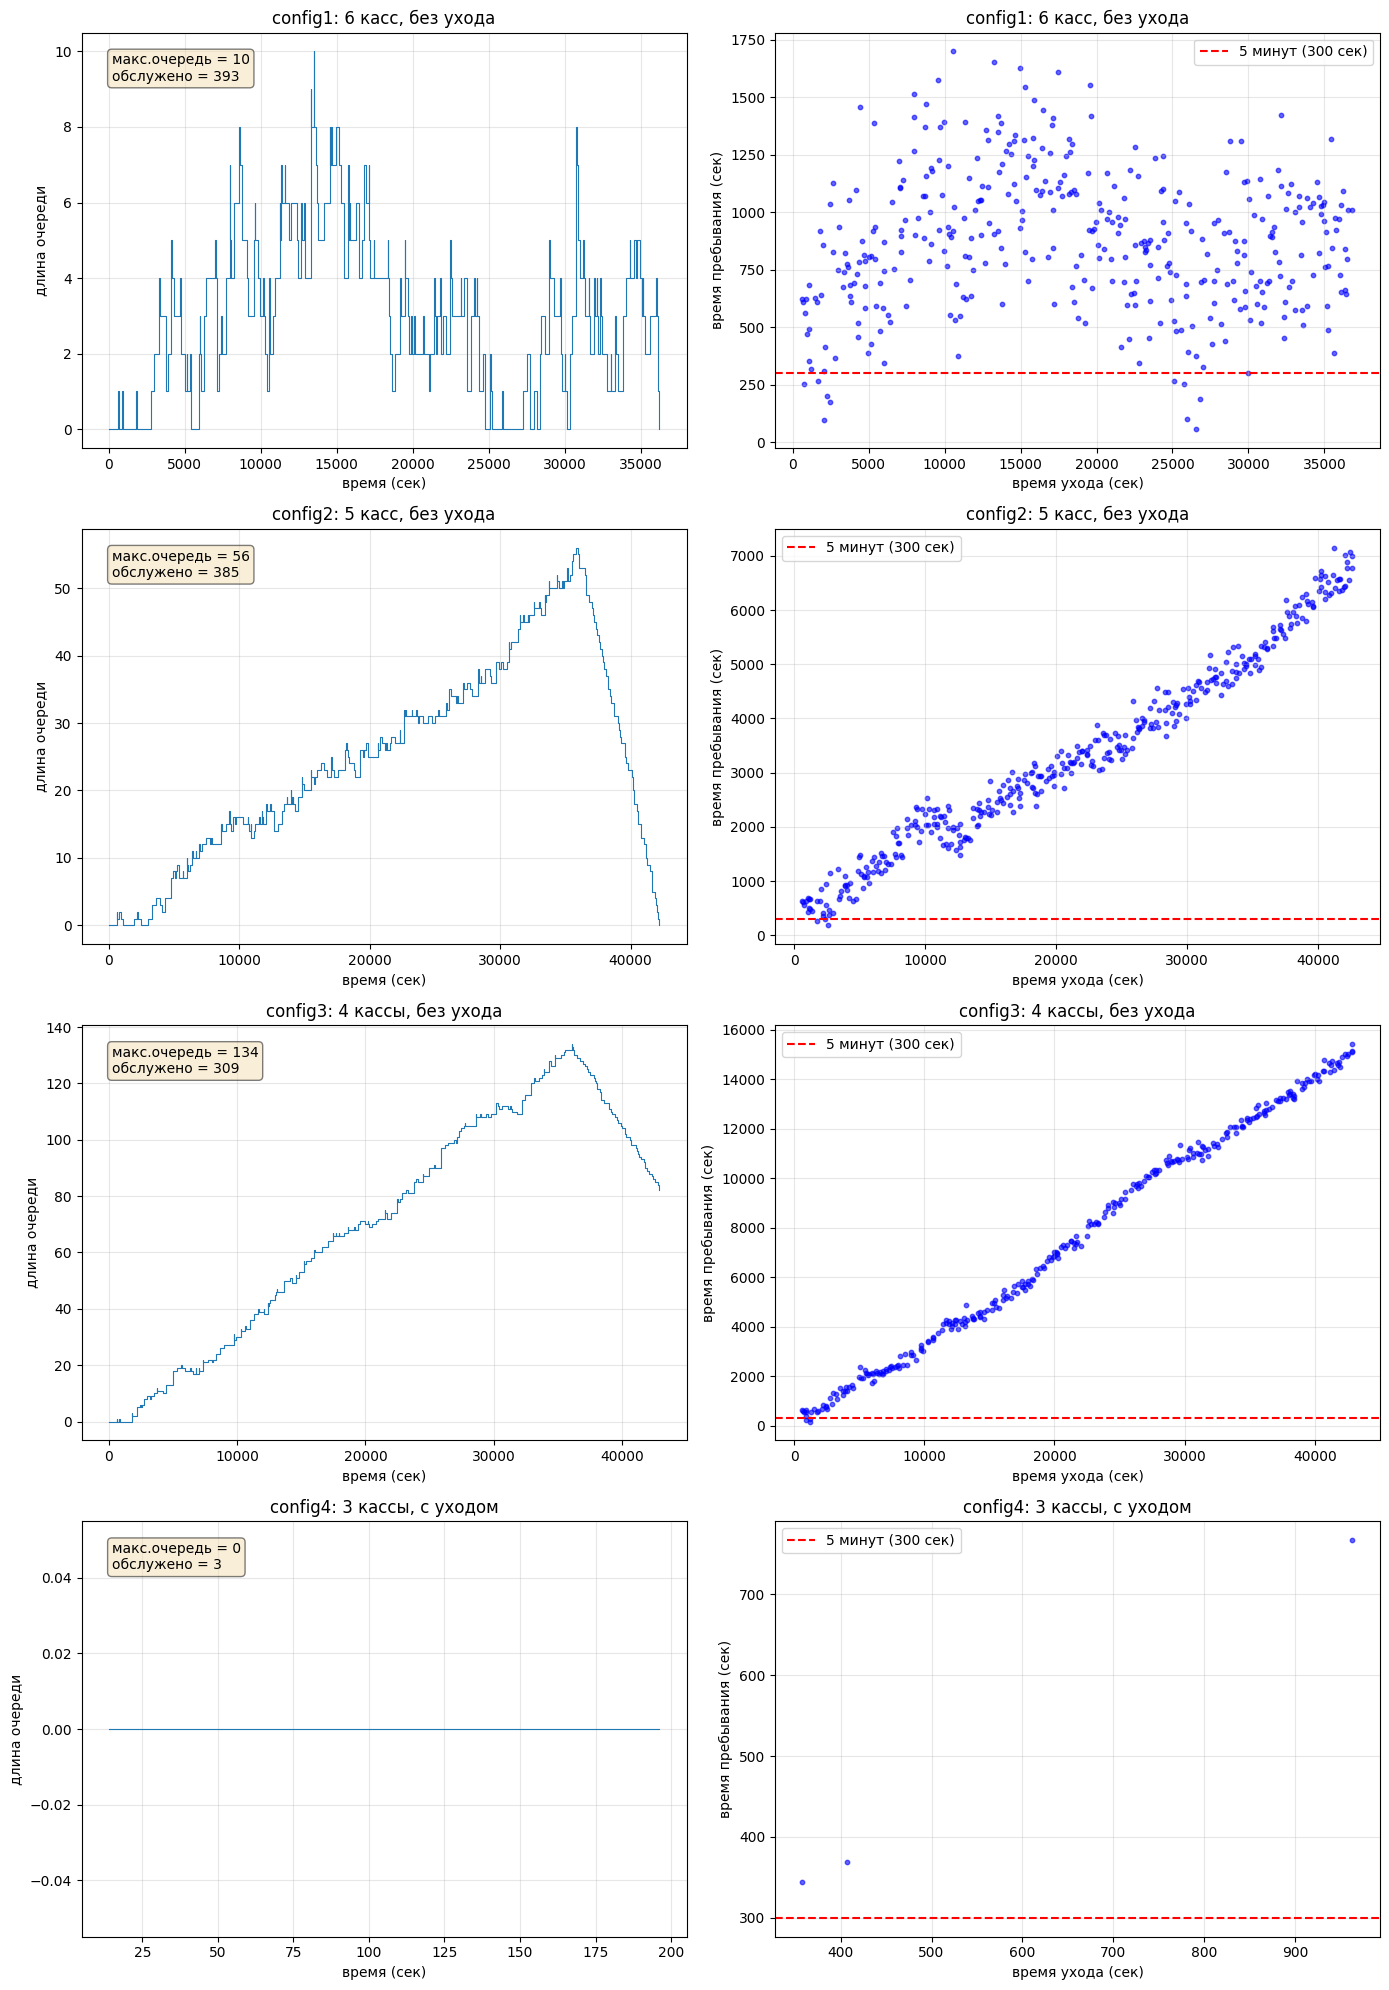


Задание 2: Сравнение config4 с уходом и без ухода

Запуск config4 без ухода (3 кассы)
Привет! Это клиент1, и я прибыл в магазин в 14 (сек)
Привет! Это клиент2, и я прибыл в магазин в 38 (сек)
Привет! Это клиент3, и я прибыл в магазин в 210 (сек)
Привет! Это клиент4, и я прибыл в магазин в 274 (сек)
Привет! Это клиент5, и я прибыл в магазин в 363 (сек)
Привет! Это клиент6, и я прибыл в магазин в 526 (сек)
Я клиент1, обслуживался 622 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=636) я ушёл.
Я клиент2, обслуживался 610 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=648) я ушёл.
Привет! Это клиент7, и я прибыл в магазин в 654 (сек)
Привет! Это клиент8, и я прибыл в магазин в 761 (сек)
Я клиент3, обслуживался 561 секунд, ждал в очереди 0 секунд
Меня обслужили, и сейчас (время=771) я ушёл.
Привет! Это клиент9, и я прибыл в магазин в 812 (сек)
Привет! Это клиент10, и я прибыл в магазин в 942 (сек)
Привет! Это клиент11, и я прибыл в магазин в 1022 (сек)
При

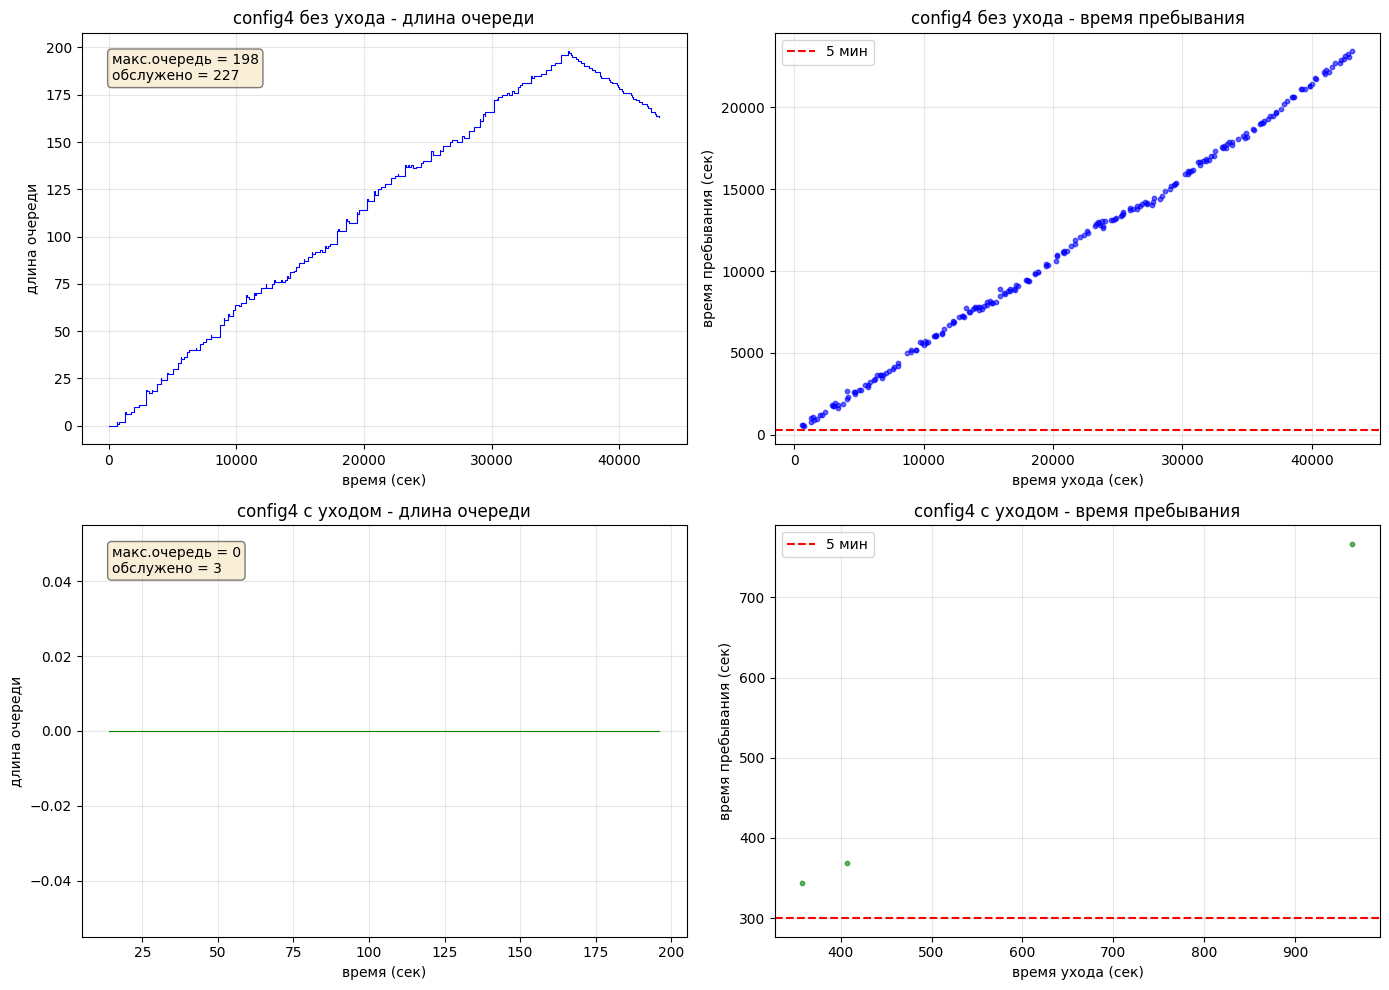


Результаты:

Задание 1:
  config1 (6 касс, без ухода): обслужено=393, макс.очередь=10
  config2 (5 касс, без ухода): обслужено=385, макс.очередь=56
  config3 (4 кассы, без ухода): обслужено=309, макс.очередь=134
  config4 (3 кассы, с уходом): обслужено=3, макс.очередь=0

Задание 2:
  config4 без ухода: доля <=5 мин = 0.0%
  config4 с уходом: доля <=5 мин = 0.0%


In [1]:
# -*- coding: utf-8 -*-
# Импорт среды SimPy
import simpy
# Для генерации случайных чисел
import random
import matplotlib.pyplot as plt

# Единица модельного времени = 1 секунда реального времени

# Длительность получения услуги
MAX_SERVICE_DURATION = 20 * 60  # т.е. максимальная длительность обслуживания 20 мин
MODE_SERVICE_DURATION = 7 * 60  # индивидуальное время обслуживания треугольно распределенной
# случайной величине на интервале [30, 20*60, 7*60]

# макс.интервал до появления нового покупателя
ARRIV_INTER = 3 * 60
# время появления нового покупателя равномерно распределенная
# случайная величина на интервале [0, 3*60]

# Время работы магазина (10 часов)
# После 10 часов работы магазин закрывают и обслуживают только оставшихся
CONSUMER_TIME = 3600 * 10

# ------------ Служебные параметры для статистики --------
myquelen = 0  # Текущая длина очереди
quelog = [] # журнал длины очереди
tservlog =[] # журнал пребывания в системе

# Класс - покупатель магазина - логический блок-процессор
class Client(object):
    def __init__(self, env, res, name='client'):
        self.name = name  # Имя покупателя, чтобы их различать
        self.env = env  # Среда моделирования
        self.res = res  # используемый при моделировании ресурс- касса

    def run(self):
        # ссылка на глобальные счетчики статистики
        # для графиков после моделирования
        global myquelen, quelog, tservlog
        # клиент пришел и встал в очередь: она увеличилась на 1
        # Запомним время, чтобы посчитать потом время пребывания в магазине
        timeq = self.env.now
        print(f"Привет! Это {self.name}, и я прибыл в магазин в {timeq} (сек)")
        # Запрос свободной кассы
        with self.res.request() as req:
            # Нет свободной кассы? в очередь
            yield req
            # Свободная касса появилась!
            # клиент поступает на обслуживание и очередь уменьшается на 1
            # запомним текущую длину очереди и текущее время события
            wait = self.env.now
            quelog.append((wait, len(self.res.queue)))
            # время обслуживания - случайное число, генерируем его
            serving_duration = int(random.triangular(30, MAX_SERVICE_DURATION, MODE_SERVICE_DURATION))
            # обслуживаемся в кассе!
            yield self.env.timeout(serving_duration)
            # Обслужились и освободили кассу
            # переменная (wait-timeq) - время, проведенное в очереди
            print(f"Я {self.name}, обслуживался {serving_duration} секунд, ждал в очереди {wait-timeq} секунд")
            # Запомним время проведенное в магазине
            # Запомним текущее время события - клиент ушел
            tservlog.append((self.env.now, self.env.now-timeq))
            print(f"Меня обслужили, и сейчас (время={self.env.now}) я ушёл.")

# Класс с уходом из очереди
class ClientWithBalk(object):
    def __init__(self, env, res, name='client'):
        self.name = name
        self.env = env
        self.res = res

    def run(self):
        global myquelen, quelog, tservlog
        timeq = self.env.now
        print(f"Привет! Это {self.name}, и я прибыл в магазин в {timeq} (сек)")
        
        patience = random.randint(120, 300)
        req = self.res.request()
        results = yield req | self.env.timeout(patience)
        
        if req in results:
            wait = self.env.now
            quelog.append((wait, len(self.res.queue)))
            serving_duration = int(random.triangular(30, MAX_SERVICE_DURATION, MODE_SERVICE_DURATION))
            yield self.env.timeout(serving_duration)
            print(f"Я {self.name}, обслуживался {serving_duration} секунд, ждал в очереди {wait-timeq} секунд")
            tservlog.append((self.env.now, self.env.now-timeq))
            print(f"Меня обслужили, и сейчас (время={self.env.now}) я ушёл.")
        else:
            print(f"Клиент {self.name} ушёл через {patience} сек (не дождался)")

def run_simulation(capacity, with_balking, run_time=12*3600):
    global myquelen, quelog, tservlog
    myquelen = 0
    quelog = []
    tservlog = []
    
    env = simpy.Environment()
    cashier = simpy.Resource(env, capacity=capacity)
    
    def source_men(env):
        ind = 0
        while env.now < (CONSUMER_TIME - ARRIV_INTER):
            ind += 1
            yield env.timeout(random.randint(0, ARRIV_INTER))
            if with_balking:
                man = ClientWithBalk(env, cashier, name='клиент%s' % ind)
            else:
                man = Client(env, cashier, name='клиент%s' % ind)
            env.process(man.run())
    
    random.seed(13971)
    env.process(source_men(env))
    env.run(until=run_time)
    
    max_queue = max([q for _, q in quelog]) if quelog else 0
    return quelog, tservlog, max_queue

print("="*60)
print("Запуск config1: capacity=6 (без ухода)")
print("="*60)
quelog1, tservlog1, maxq1 = run_simulation(6, False)
print(f"\nconfig1: обслужено={len(tservlog1)}, макс.очередь={maxq1}\n")

print("="*60)
print("Запуск config2: capacity=5 (без ухода)")
print("="*60)
quelog2, tservlog2, maxq2 = run_simulation(5, False)
print(f"\nconfig2: обслужено={len(tservlog2)}, макс.очередь={maxq2}\n")

print("="*60)
print("Запуск config3: capacity=4 (без ухода)")
print("="*60)
quelog3, tservlog3, maxq3 = run_simulation(4, False)
print(f"\nconfig3: обслужено={len(tservlog3)}, макс.очередь={maxq3}\n")

print("="*60)
print("Запуск config4: capacity=3 (с уходом)")
print("="*60)
quelog4, tservlog4, maxq4 = run_simulation(3, True)
print(f"\nconfig4: обслужено={len(tservlog4)}, макс.очередь={maxq4}\n")

# Задание 1: графики для 4х конфигураций
print("\n" + "="*60)
print("Задание 1: Построение графиков")
print("="*60)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
all_quelog = [quelog1, quelog2, quelog3, quelog4]
all_tservlog = [tservlog1, tservlog2, tservlog3, tservlog4]
all_maxq = [maxq1, maxq2, maxq3, maxq4]
all_served = [len(tservlog1), len(tservlog2), len(tservlog3), len(tservlog4)]
titles = ['config1: 6 касс, без ухода', 'config2: 5 касс, без ухода', 
          'config3: 4 кассы, без ухода', 'config4: 3 кассы, с уходом']

for idx in range(4):
    ax1 = axes[idx, 0]
    times = [t for t, _ in all_quelog[idx]]
    lengths = [l for _, l in all_quelog[idx]]
    ax1.step(times, lengths, where='post', linewidth=0.8)
    ax1.set_xlabel('время (сек)')
    ax1.set_ylabel('длина очереди')
    ax1.set_title(titles[idx])
    ax1.grid(True, alpha=0.3)
    ax1.text(0.05, 0.95, f'макс.очередь = {all_maxq[idx]}\nобслужено = {all_served[idx]}',
             transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax2 = axes[idx, 1]
    if all_tservlog[idx]:
        times = [t for t, _ in all_tservlog[idx]]
        totals = [tot for _, tot in all_tservlog[idx]]
        ax2.scatter(times, totals, s=10, alpha=0.6, color='blue')
    ax2.set_xlabel('время ухода (сек)')
    ax2.set_ylabel('время пребывания (сек)')
    ax2.set_title(titles[idx])
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=300, color='red', linestyle='--', label='5 минут (300 сек)')
    ax2.legend()

plt.tight_layout()
plt.show()

# Задание 2: сравнение config4 с уходом и без
print("\n" + "="*60)
print("Задание 2: Сравнение config4 с уходом и без ухода")
print("="*60)

print("\nЗапуск config4 без ухода (3 кассы)")
quelog4_no, tservlog4_no, maxq4_no = run_simulation(3, False)
print(f"\nбез ухода: обслужено={len(tservlog4_no)}, макс.очередь={maxq4_no}")

print("\nЗапуск config4 с уходом (3 кассы)")
quelog4_yes, tservlog4_yes, maxq4_yes = run_simulation(3, True)
print(f"\nс уходом: обслужено={len(tservlog4_yes)}, макс.очередь={maxq4_yes}")

def fast_ratio(tservlog):
    if not tservlog:
        return 0
    fast = sum(1 for _, total in tservlog if total <= 300)
    return fast / len(tservlog)

r1 = fast_ratio(tservlog4_no)
r2 = fast_ratio(tservlog4_yes)

print("\nДоля клиентов с временем пребывания не более 5 минут:")
print(f"без ухода: {r1*100:.1f}%")
print(f"с уходом: {r2*100:.1f}%")

# Графики для сравнения config4
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
times = [t for t, _ in quelog4_no]
lengths = [l for _, l in quelog4_no]
ax.step(times, lengths, where='post', color='blue', linewidth=0.8)
ax.set_title('config4 без ухода - длина очереди')
ax.set_xlabel('время (сек)')
ax.set_ylabel('длина очереди')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'макс.очередь = {maxq4_no}\nобслужено = {len(tservlog4_no)}',
        transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax = axes[0, 1]
if tservlog4_no:
    times = [t for t, _ in tservlog4_no]
    totals = [tot for _, tot in tservlog4_no]
    ax.scatter(times, totals, s=10, alpha=0.6, color='blue')
ax.axhline(y=300, color='red', linestyle='--', label='5 мин')
ax.set_title('config4 без ухода - время пребывания')
ax.set_xlabel('время ухода (сек)')
ax.set_ylabel('время пребывания (сек)')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
times = [t for t, _ in quelog4_yes]
lengths = [l for _, l in quelog4_yes]
ax.step(times, lengths, where='post', color='green', linewidth=0.8)
ax.set_title('config4 с уходом - длина очереди')
ax.set_xlabel('время (сек)')
ax.set_ylabel('длина очереди')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'макс.очередь = {maxq4_yes}\nобслужено = {len(tservlog4_yes)}',
        transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax = axes[1, 1]
if tservlog4_yes:
    times = [t for t, _ in tservlog4_yes]
    totals = [tot for _, tot in tservlog4_yes]
    ax.scatter(times, totals, s=10, alpha=0.6, color='green')
ax.axhline(y=300, color='red', linestyle='--', label='5 мин')
ax.set_title('config4 с уходом - время пребывания')
ax.set_xlabel('время ухода (сек)')
ax.set_ylabel('время пребывания (сек)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Результаты:")
print("="*60)
print("\nЗадание 1:")
print(f"  config1 (6 касс, без ухода): обслужено={len(tservlog1)}, макс.очередь={maxq1}")
print(f"  config2 (5 касс, без ухода): обслужено={len(tservlog2)}, макс.очередь={maxq2}")
print(f"  config3 (4 кассы, без ухода): обслужено={len(tservlog3)}, макс.очередь={maxq3}")
print(f"  config4 (3 кассы, с уходом): обслужено={len(tservlog4)}, макс.очередь={maxq4}")

print("\nЗадание 2:")
print(f"  config4 без ухода: доля <=5 мин = {r1*100:.1f}%")
print(f"  config4 с уходом: доля <=5 мин = {r2*100:.1f}%")